# Capas Convolucionales en Redes Neuronales — Deteccion de Enfermedades en Hojas de Banano
**Dataset:** BananaLSD (Banana Leaf Spot Diseases Dataset)

Las enfermedades foliares (manchas y hongos en las hojas) reducen significativamente la produccion y si no se detectan a tiempo, pueden causar perdidas economicas considerables a los productores.

Este notebook explora el uso de **redes neuronales convolucionales (CNN)** para clasificar imagenes de hojas de banano en distintas categorias, comparando su desempenio contra una red totalmente conectada (baseline) y analizando como las decisiones arquitectonicas de la capa convolucional afectan el aprendizaje.

El dataset **BananaLSD** contiene imagenes de hojas de banano tomadas en campo con camaras de celular, en condiciones reales (variacion de luz, fondo y angulo). Incluye 4 clases: hoja **sana** y tres enfermedades **Sigatoka**, **Cordana** y **Pestalotiopsis**.

In [22]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU disponible: []


##### **Exploracion del Dataset(EDA)**

- Tamaño del dataset y distribución de clases
- Dimensiones de las imágenes y número de canales
- Ejemplos de muestras por clase
- Preprocesamiento necesario (normalización, redimensionamiento)

In [23]:
#Necesitamos primero identificar las clases que tenemos en el dataset.
#Para ello, vamos a leer la carpeta donde se encuentra el dataset y
#vamos a listar las subcarpetas que contiene. Cada subcarpeta 
#corresponde a una clase.
DATA_DIR = Path("archive/BananaLSD/OriginalSet")  

assert DATA_DIR.exists(), (f"No se encontró {DATA_DIR}. Descarga el dataset de Kaggle y colócalo en esa ruta.")

class_names = []
for i in DATA_DIR.iterdir():
    if i.is_dir():
        class_names.append(i.name)
class_names = sorted(class_names)
print("Clases encontradas:", class_names)

Clases encontradas: ['cordana', 'healthy', 'pestalotiopsis', 'sigatoka']


##### Tamaño del dataset y distribución de clases

In [24]:
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

In [25]:
def contar_imagenes_por_clase(data_dir, class_names, extensions=(".jpg", ".jpeg", ".png")):
    """Cuenta cuántas imágenes hay en cada carpeta de clase."""
    distribucion_clases = {}
    for c in class_names:
        #contiene la ubicación de la carpeta de la clase actual
        class_dir = DATA_DIR / c
        imagenes = []
        for a in class_dir.iterdir():
            #verificamos que el archivo sea una imagen
            if a.suffix.lower() in IMAGE_EXTENSIONS:
                imagenes.append(a)
        n_images = len(imagenes)
        distribucion_clases[c] = n_images
    return distribucion_clases

In [26]:
def graficar_distribucion(counts, titulo="Distribución de clases"):
    """Dibuja una gráfica de barras a partir de un diccionario clase -> cantidad."""
    total = sum(counts.values())
    print(f"Total de imágenes: {total}\n")
    for cls, n in counts.items():
        print(f"  {cls:20s}: {n:5d} imágenes ({100 * n / total:.1f}%)")

    plt.figure()
    plt.bar(counts.keys(), counts.values(), color="#814C9A")
    plt.ylabel("Número de imágenes")
    plt.title(titulo)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

Total de imágenes: 937

  cordana             :   162 imágenes (17.3%)
  healthy             :   129 imágenes (13.8%)
  pestalotiopsis      :   173 imágenes (18.5%)
  sigatoka            :   473 imágenes (50.5%)


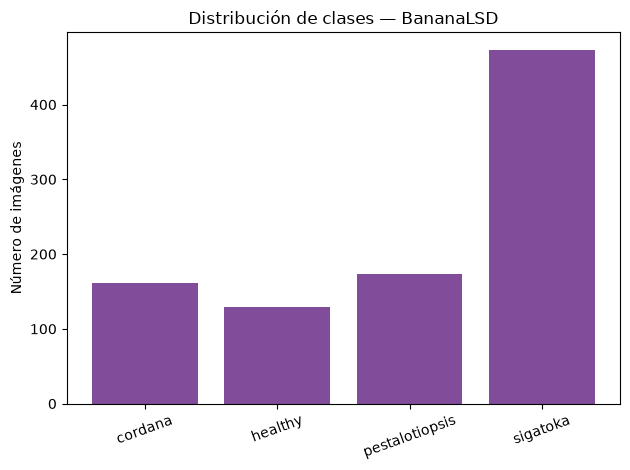

In [27]:
# 3.1 distribución de clases
counts = contar_imagenes_por_clase(DATA_DIR, class_names)
graficar_distribucion(counts, titulo="Distribución de clases — BananaLSD")

##### Dimensiones de las imágenes y número de canales

In [32]:
def muestrear_dimensiones(data_dir, class_names, n_por_clase=20, extensions=(".jpg", ".jpeg", ".png")):
    """Abre una muestra de imágenes por clase y devuelve sus tamaños y número de canales."""
    dimensiones, canales = [], []
    for c in class_names:
        class_dir = data_dir / c
        imagenes = []
        for a in class_dir.iterdir():
            if a.suffix.lower() in IMAGE_EXTENSIONS:
                imagenes.append(a)

        for a in imagenes:
            with Image.open(a) as img:
                dimensiones.append(img.size)
                canales.append(len(img.getbands()))
    return dimensiones, canales

In [33]:
# 3.2 dimensiones y canales
sizes, canales = muestrear_dimensiones(DATA_DIR, class_names)
print("Dimensiones: ", set(sizes))
print("Número de canales: ", set(canales))

Dimensiones:  {(224, 224)}
Número de canales:  {3}


##### Ejemplos de muestras por clase

In [30]:
def graficar_ejemplos_por_clase(data_dir,class_names,n_ejemplos=4,extensions=(".jpg", ".jpeg", ".png")):
    """Muestra una cuadrícula con n_ejemplos imágenes de cada clase."""

    num_classes = len(class_names)

    fig, axes = plt.subplots(num_classes,n_ejemplos)

    for row, cls in enumerate(class_names):
        cls_dir = data_dir / cls
        imagenes = []

        for f in cls_dir.iterdir():
            if f.suffix.lower() in extensions:
                imagenes.append(f)

        cantidad = min(n_ejemplos, len(imagenes))
        sample = random.sample(imagenes, cantidad)

        for col, f in enumerate(sample):
            img = Image.open(f)
            if num_classes > 1:
                ax = axes[row, col]
            else:
                ax = axes[col]

            ax.imshow(img)
            ax.axis("off")

        axes[row, 0].set_title(cls,loc="left",fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

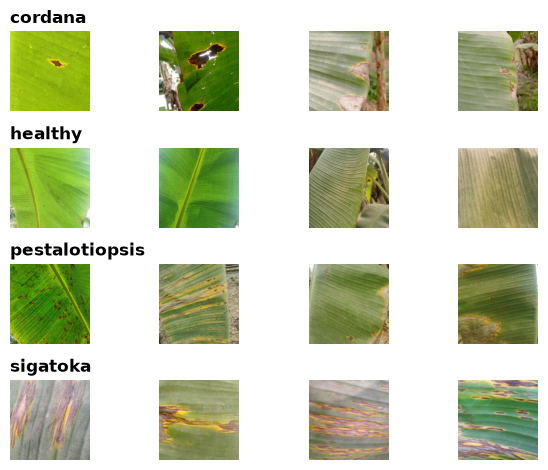

In [31]:
# 3.3 ejemplos visuales
graficar_ejemplos_por_clase(DATA_DIR, class_names)

##### Preprocesamiento necesario (normalización, redimensionamiento)

**Redimensionamiento**
En el punto anterior 3.2 se evidencia que las imagenes son de 224×224 píxeles, por que en un incio y si quiseramos podriamos manejarlo asi, ya que estan uniformes, pero hay que tener un aspecto importante que son los numeros de parametros que pasamos, en 224px son mucho mas que en 128px, por lo cual seria más rapido de entrenar.

**Normalizacion**
Los píxeles de las imágenes van de 0 a 255. Vamos a pasarlos a un rango de 0 a 1, dividiendo cada valor entre 255. Esto se hace porque las redes neuronales entrenan mejor y más rápido cuando trabajan con números pequeños, en vez de números grandes como 255.

**Canales**
En el punto 3.2 confirmamos que todas las imágenes son a color, con 3 canales (RGB). No hay que hacer ningún cambio aquí, ya vienen uniformes.

**Balanceo de clases**
En el punto 3.1 vimos que las clases no están balanceadas: la clase sigatoka tiene 473 imágenes (50.5% del total), mientras que healthy solo tiene 129 (13.8%). Es decir, hay más del triple de imágenes de sigatoka que de healthy.

Esto es importante porque si no lo tenemos en cuenta, el modelo podría "hacer trampa": como sigatoka tiene tantas imágenes, el modelo podría aprender a predecir casi siempre sigatoka y aun así tener un buen porcentaje de aciertos (accuracy), sin haber aprendido realmente a distinguir las enfermedades. Por eso, además del accuracy, vamos a revisar otras métricas más adelante (como la matriz de confusión) para asegurarnos de que el modelo esté aprendiendo bien todas las clases, no solo la más grande.
